# Synthetic Alfven Wave Validation

This notebook validates the FFT methods by generating a synthetic Alfven wave and demonstrating that:
1. The spatial FFT recovers the correct wavenumber k₀
2. The time FFT recovers the correct frequency ω₀
3. The k-ω spectrum shows power along the Alfven dispersion relation ω = k × v_A

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from reconn_wave_power.spectrum import compute_psd_time, compute_psd_space, compute_komega_2d

%matplotlib inline

## Wave Parameters

We generate an Alfven-like wave with dispersion relation ω = k × v_A:

$$B_z(x, t) = B_0 \sin(k_0 x - \omega_0 t)$$

In [2]:
# Wave parameters
V_A = 1.0          # Normalized Alfven speed
WAVELENGTH = 10.0  # Grid units
K0 = 2 * np.pi / WAVELENGTH  # Wavenumber (rad/unit)
OMEGA0 = K0 * V_A  # Angular frequency (rad/unit time)
F0 = OMEGA0 / (2 * np.pi)  # Frequency in cycles
B0 = 1.0           # Amplitude

print(f"Alfven speed v_A = {V_A}")
print(f"Wavelength λ = {WAVELENGTH}")
print(f"Wavenumber k₀ = {K0:.4f} rad/unit")
print(f"Angular frequency ω₀ = {OMEGA0:.4f} rad/unit time")
print(f"Frequency f₀ = {F0:.4f} cycles/unit time")

Alfven speed v_A = 1.0
Wavelength λ = 10.0
Wavenumber k₀ = 0.6283 rad/unit
Angular frequency ω₀ = 0.6283 rad/unit time
Frequency f₀ = 0.1000 cycles/unit time


In [3]:
# Grid setup
dx = 0.5
dt = 0.1
x = np.arange(0, 100.0, dx)
t = np.arange(0, 100.0, dt)

print(f"Spatial grid: {len(x)} points, dx = {dx}")
print(f"Temporal grid: {len(t)} points, dt = {dt}")

Spatial grid: 200 points, dx = 0.5
Temporal grid: 1000 points, dt = 0.1


In [4]:
# Generate the wave B_z(x, t)
X, T = np.meshgrid(x, t, indexing='ij')
Bz = B0 * np.sin(K0 * X - OMEGA0 * T)

print(f"Wave array shape: {Bz.shape} (x, t)")

Wave array shape: (200, 1000) (x, t)


## 1. Real Space vs k-Space (Spatial FFT)

We extract a spatial profile at a fixed time and compute the spatial power spectrum. The peak should occur at k₀.

In [5]:
# Extract spatial profile at t = 50 (middle of time range)
t_idx = len(t) // 2
spatial_profile = Bz[:, t_idx]

# Create DataArray for spectrum computation
da_space = xr.DataArray(spatial_profile, dims=("x",), coords={"x": x})

# Compute spatial PSD
k_rad, Pk = compute_psd_space(da_space, dx=dx, axis="x", window=None)

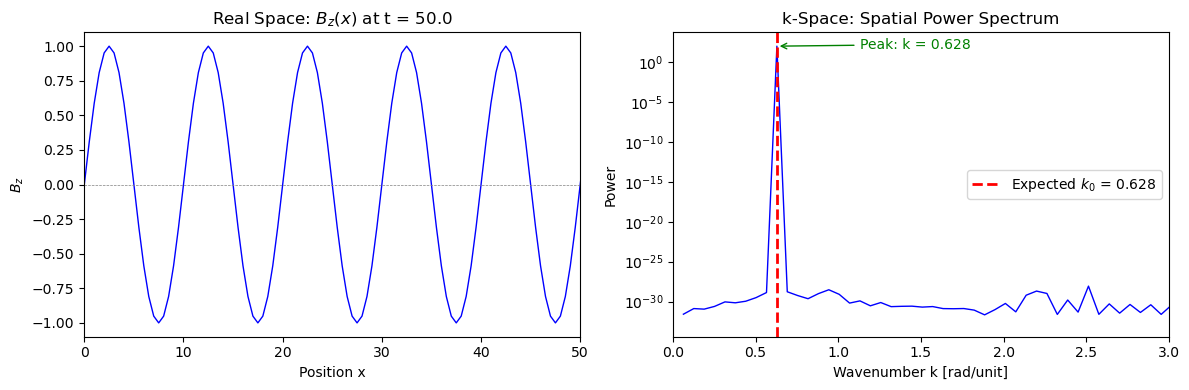


Expected k₀ = 0.6283 rad/unit
Recovered k  = 0.6283 rad/unit
Error: 0.000000 (0.00%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Real space
ax1 = axes[0]
ax1.plot(x, spatial_profile, 'b-', lw=1)
ax1.set_xlabel('Position x')
ax1.set_ylabel('$B_z$')
ax1.set_title(f'Real Space: $B_z(x)$ at t = {t[t_idx]:.1f}')
ax1.axhline(0, color='gray', lw=0.5, ls='--')
ax1.set_xlim(0, 50)  # Show a few wavelengths

# Right: k-space
ax2 = axes[1]
# Only show positive k
pos_mask = k_rad > 0
ax2.semilogy(k_rad[pos_mask], Pk[pos_mask], 'b-', lw=1)
ax2.axvline(K0, color='r', lw=2, ls='--', label=f'Expected $k_0$ = {K0:.3f}')
ax2.set_xlabel('Wavenumber k [rad/unit]')
ax2.set_ylabel('Power')
ax2.set_title('k-Space: Spatial Power Spectrum')
ax2.legend()
ax2.set_xlim(0, 3)

# Find and annotate the peak
peak_idx = np.argmax(Pk[pos_mask])
peak_k = k_rad[pos_mask][peak_idx]
ax2.annotate(f'Peak: k = {peak_k:.3f}', 
             xy=(peak_k, Pk[pos_mask][peak_idx]),
             xytext=(peak_k + 0.5, Pk[pos_mask][peak_idx] * 0.5),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')

plt.tight_layout()
plt.show()

print(f"\nExpected k₀ = {K0:.4f} rad/unit")
print(f"Recovered k  = {peak_k:.4f} rad/unit")
print(f"Error: {abs(peak_k - K0):.6f} ({abs(peak_k - K0)/K0*100:.2f}%)")

## 2. Time Series vs Frequency Space (Temporal FFT)

We extract a time series at a fixed spatial location and compute the time-domain power spectrum. The peak should occur at f₀ = ω₀/(2π).

In [7]:
# Extract time series at x = 50 (middle of spatial domain)
x_idx = len(x) // 2
time_series = Bz[x_idx, :]

# Create DataArray for spectrum computation
da_time = xr.DataArray(time_series, dims=("time",), coords={"time": t})

# Compute time PSD using Welch's method
f, Pxx = compute_psd_time(da_time, dt=dt, nperseg=256)

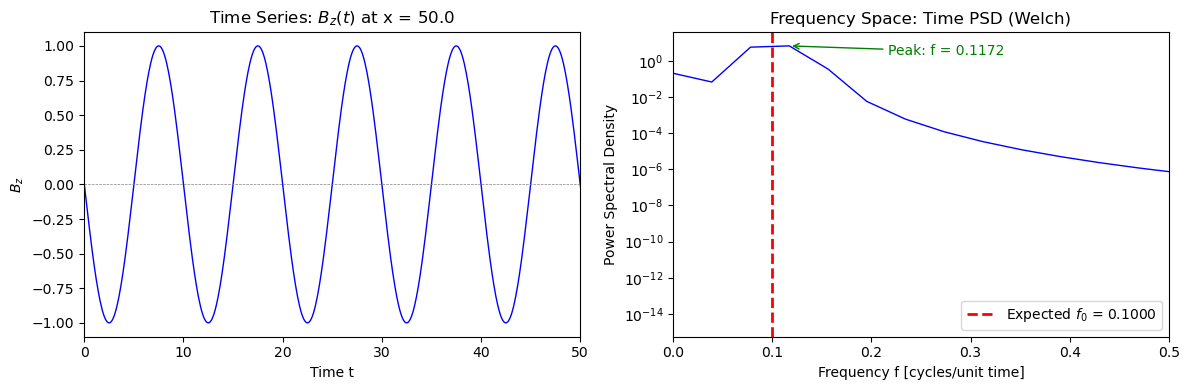


Expected f₀ = 0.1000 cycles/unit time
Recovered f  = 0.1172 cycles/unit time
Error: 0.017187 (17.19%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Time series
ax1 = axes[0]
ax1.plot(t, time_series, 'b-', lw=1)
ax1.set_xlabel('Time t')
ax1.set_ylabel('$B_z$')
ax1.set_title(f'Time Series: $B_z(t)$ at x = {x[x_idx]:.1f}')
ax1.axhline(0, color='gray', lw=0.5, ls='--')
ax1.set_xlim(0, 50)  # Show a few periods

# Right: Frequency space
ax2 = axes[1]
ax2.semilogy(f, Pxx, 'b-', lw=1)
ax2.axvline(F0, color='r', lw=2, ls='--', label=f'Expected $f_0$ = {F0:.4f}')
ax2.set_xlabel('Frequency f [cycles/unit time]')
ax2.set_ylabel('Power Spectral Density')
ax2.set_title('Frequency Space: Time PSD (Welch)')
ax2.legend()
ax2.set_xlim(0, 0.5)

# Find and annotate the peak
peak_idx = np.argmax(Pxx)
peak_f = f[peak_idx]
ax2.annotate(f'Peak: f = {peak_f:.4f}', 
             xy=(peak_f, Pxx[peak_idx]),
             xytext=(peak_f + 0.1, Pxx[peak_idx] * 0.3),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')

plt.tight_layout()
plt.show()

print(f"\nExpected f₀ = {F0:.4f} cycles/unit time")
print(f"Recovered f  = {peak_f:.4f} cycles/unit time")
print(f"Error: {abs(peak_f - F0):.6f} ({abs(peak_f - F0)/F0*100:.2f}%)")

## 3. k-ω Spectrum (2D FFT)

We compute the full 2D k-ω spectrum and verify that the power is concentrated along the Alfven dispersion relation ω = k × v_A.

In [9]:
# Compute k-omega spectrum
# axes=(0, 1) means axis 0 is space, axis 1 is time
k_rad, omega, P = compute_komega_2d(Bz, dx=dx, dt=dt, axes=(0, 1))

print(f"k range: [{k_rad.min():.3f}, {k_rad.max():.3f}] rad/unit")
print(f"ω range: [{omega.min():.3f}, {omega.max():.3f}] rad/unit time")
print(f"Power array shape: {P.shape}")

k range: [-6.283, 6.220] rad/unit
ω range: [-31.416, 31.353] rad/unit time
Power array shape: (200, 1000)


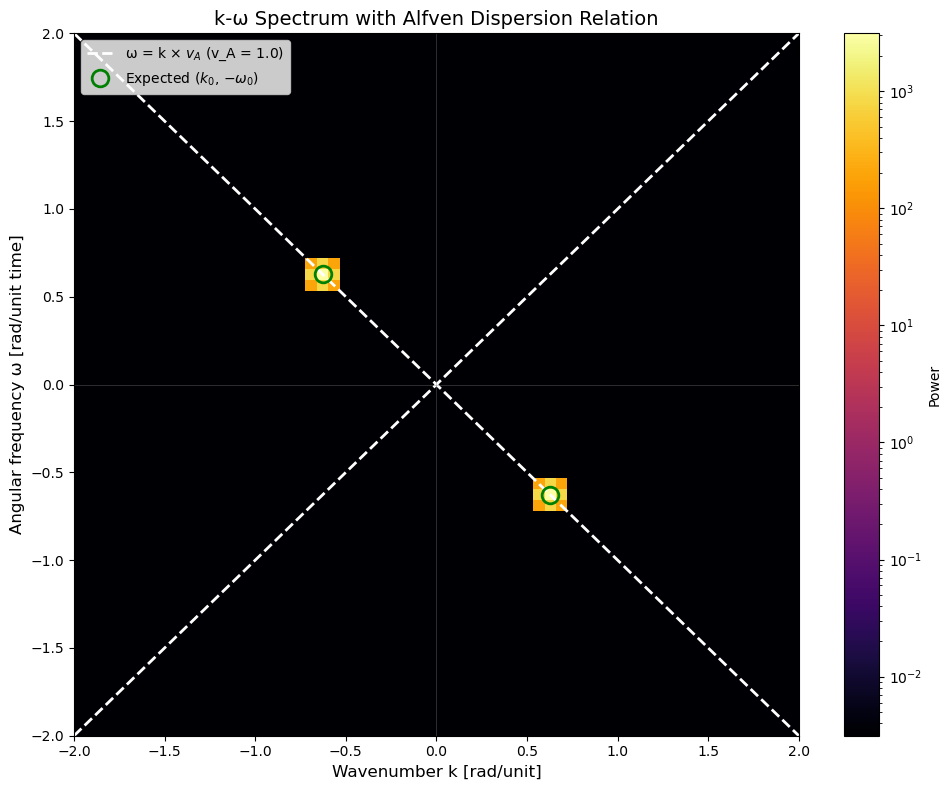

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

# Plot k-omega spectrum with log color scale
# Limit the range to see the relevant region
k_lim = 2.0
omega_lim = 2.0

im = ax.pcolormesh(k_rad, omega, P.T, shading='auto', cmap='inferno',
                   norm=plt.matplotlib.colors.LogNorm(vmin=P.max()*1e-6, vmax=P.max()))
plt.colorbar(im, ax=ax, label='Power')

# Plot the Alfven dispersion relation ω = k × v_A
k_line = np.linspace(-k_lim, k_lim, 100)
omega_line = k_line * V_A
ax.plot(k_line, omega_line, 'w--', lw=2, label=f'ω = k × $v_A$ (v_A = {V_A})')
ax.plot(k_line, -omega_line, 'w--', lw=2)  # Negative branch

# Mark the expected wave location
ax.plot(K0, -OMEGA0, 'go', ms=12, mew=2, mfc='none', label=f'Expected ($k_0$, $-ω_0$)')
ax.plot(-K0, OMEGA0, 'go', ms=12, mew=2, mfc='none')

ax.set_xlabel('Wavenumber k [rad/unit]', fontsize=12)
ax.set_ylabel('Angular frequency ω [rad/unit time]', fontsize=12)
ax.set_title('k-ω Spectrum with Alfven Dispersion Relation', fontsize=14)
ax.set_xlim(-k_lim, k_lim)
ax.set_ylim(-omega_lim, omega_lim)
ax.legend(loc='upper left')
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [11]:
# Find the peak and verify dispersion relation
peak_idx = np.unravel_index(np.argmax(P), P.shape)
peak_k = k_rad[peak_idx[0]]
peak_omega = omega[peak_idx[1]]

# The wave sin(k0*x - omega0*t) produces peaks at (+k0, -omega0) and (-k0, +omega0)
recovered_va = abs(peak_omega) / abs(peak_k)

print("Peak Location:")
print(f"  k = {peak_k:.4f} rad/unit (expected |k₀| = {K0:.4f})")
print(f"  ω = {peak_omega:.4f} rad/unit time (expected |ω₀| = {OMEGA0:.4f})")
print(f"\nDispersion Relation Check:")
print(f"  Recovered v_A = |ω|/|k| = {recovered_va:.4f}")
print(f"  Expected v_A = {V_A:.4f}")
print(f"  Error: {abs(recovered_va - V_A):.6f} ({abs(recovered_va - V_A)/V_A*100:.2f}%)")

Peak Location:
  k = -0.6283 rad/unit (expected |k₀| = 0.6283)
  ω = 0.6283 rad/unit time (expected |ω₀| = 0.6283)

Dispersion Relation Check:
  Recovered v_A = |ω|/|k| = 1.0000
  Expected v_A = 1.0000
  Error: 0.000000 (0.00%)


## Summary

The FFT methods correctly recover:
1. **Spatial wavenumber k₀** from the spatial profile
2. **Temporal frequency f₀** from the time series
3. **Alfven dispersion relation ω = k × v_A** from the 2D k-ω spectrum

This validates that the spectral analysis tools in `reconn_wave_power.spectrum` are working correctly and can be applied to real simulation data to identify wave modes.